# Импорт библиотек

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import *
from scipy.optimize import fsolve

# Задание 1

### Отделите корни заданного уравнения, пользуясь графическим методом и с применением одного из инструментальных средств.

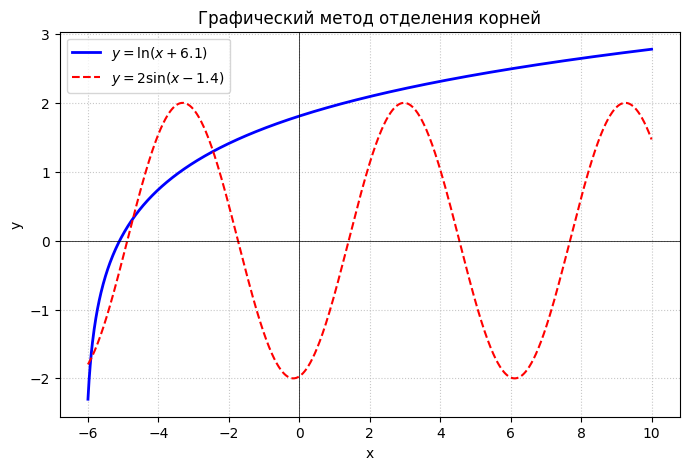

In [6]:
def f1(x):
    return np.log(x + 6.1)

def f2(x):
    return 2 * np.sin(x - 1.4)


# Если f_diff = 0, то корень найден.
def f_diff(x):
    return f1(x) - f2(x)


# Диапазон x (с учетом области определения ln: x > -6.1)
x_plot = np.linspace(-6.0, 10, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, f1(x_plot), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x_plot, f2(x_plot), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')


# Оформление
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

На графике видно, что корни примерно находятся в районах по оси х: -6; -5 и -2. Я использую библиотеку SciPy для вывода корней.

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_27892\605497140.py:2: RuntimeWarning: divide by zero encountered in log
  return np.log(x + 6.1)


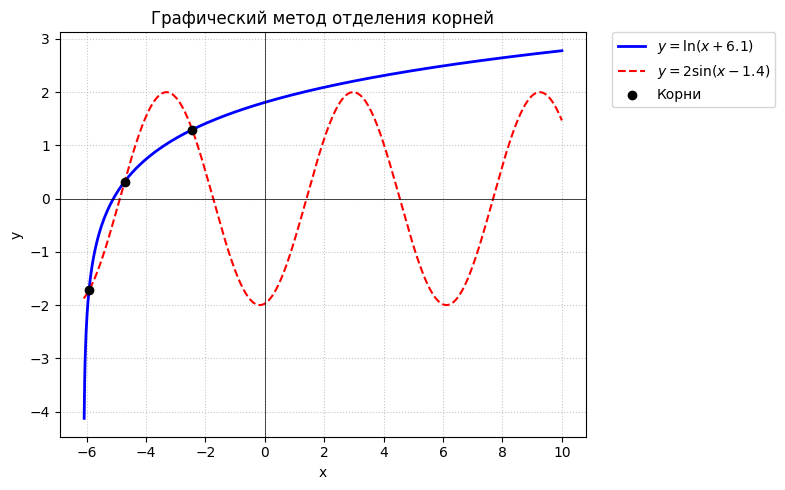

Найденные корни уравнения ln(x + 6.1) = 2*sin(x - 1.4): 
x1 ≈ -5.921
x2 ≈ -4.722
x3 ≈ -2.446


In [7]:
initial_guesses = [-6, -5, -2]
roots = fsolve(f_diff, initial_guesses)
unique_roots = np.unique(np.round(roots, 5)) # На всякий случай, если вдруг появятся дубликаты во время расчётов.


x_plot = np.linspace(-6.1, 10, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, f1(x_plot), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x_plot, f2(x_plot), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')


# Отметим корни на графике точками
plt.scatter(unique_roots, f1(unique_roots), color='black', zorder=5, label='Корни')


# Оформление
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


# Печать результата
print("Найденные корни уравнения ln(x + 6.1) = 2*sin(x - 1.4): ")
for i, root in enumerate(unique_roots, 1):
    print(f"x{i} ≈ {root:.3f}")


Уравнение имеет три действительных корня, которые приближённо находятся в окрестностях:
x1≈−5.921
x2≈−4.722
x3≈−2.446

Эти значения лежат в области определения логарифма x > -6.1, что подтверждает их корректность как решений. Они были найдены при помощи инструментального пакета SciPy.

Графически это означает, что кривая y=ln(x+6.1) пересекает синусоид y=2sin(x−1.4) в трёх точках на интервале примерно (−6.1, -2). Такое число корней отражает сочетание медленного подъёма логарифма и осциллирующего характера правой части, благодаря которому график 2sin(x−1.4) несколько раз «перескакивает» через логарифмическую кривую.

Графический метод позволяет отделить корни и приближённо указать их расположение, что удобно для дальнейшего уточнения корней численными методами (например, методом касательных или половинного деления) на каждого из полученных отрезков.

# Задание 2

### По методу половинного деления вычислите один корень заданного уравнения с точностью до 10^-3.

In [8]:
# Определяем функцию f(x) = ln(x + 6.1) - 2*sin(x - 1.4)
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def bisection_method(a, b, eps):

    # Проверка условия теоремы Больцано-Коши
    if f(a) * f(b) > 0:
        print("На данном отрезке корней нет или их четное количество")
        return None
    
    it = []
    ass = []
    bs = []
    result = []

    
    iteration = 0
    while (b - a) / 2 > eps:
        
        mid = (a + b) / 2

        # Выбираем половину отрезка, на которой функция меняет знак
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
        
        ass.append(round(a, 3))
        bs.append(round(b, 3))
        result.append(round(mid, 3))
        iteration += 1
        it.append(iteration)
    
    data = {'Итерации': it, 'a': ass, 'b': bs, 'result': result}
    df = pd.DataFrame(data)
    df = df.set_index('Итерации')

    return df, (a + b) / 2

# Беру интервал [-6;-5], потому что на этом интервале должен быть только 1 корень.
a, b = -6, -5
epsilon = 1e-3

df, root = bisection_method(a, b, epsilon)

if root is not None:
    print(df)
    print(f"\nКорень уравнения: {root:.3f}")

              a      b  result
Итерации                      
1        -6.000 -5.500  -5.500
2        -6.000 -5.750  -5.750
3        -6.000 -5.875  -5.875
4        -5.938 -5.875  -5.938
5        -5.938 -5.906  -5.906
6        -5.922 -5.906  -5.922
7        -5.922 -5.914  -5.914
8        -5.922 -5.918  -5.918
9        -5.922 -5.920  -5.920

Корень уравнения: -5.921


Метод половинного деления позволил уточнить один из корней уравнения ln(x+6.1)=2sin(x−1.4). Уравнение с точностью 10^-3, и найденное значение совпало с одним из корней, полученных ранее при графическом отделении корней, а именно x1≈−5.921. Это подтверждает корректность как графического, так и численного подхода.

Качество и надёжность метода
Метод половинного деления показал устойчивую сходимость и стабильный результат, поскольку он основан на поиске изменения знака функции на отрезке и гарантированно находит корень, если функция непрерывна и на концах отрезка значения имеют разные знаки.
Совпадение численно найденного корня с одним из графически отделённых подтверждает правильность выбора исходного отрезка и достаточность точности вычислений.

# Задание 3

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя метод простой итерации.

In [9]:
def phi(x):

    # Преобразованная функция x = exp(2*sin(x - 1.4)) - 6.1
    return np.exp(2 * np.sin(x - 1.4)) - 6.1

def simple_iteration(x0, eps):
    it = []
    x_olds = []
    x_news = []
    
    x_old = x0
    x_new = phi(x_old)
    iterations = 1

    it.append(iterations)
    x_olds.append(x_old)
    x_news.append(x_new)

    # Итерируем, пока разность соседних приближений больше eps
    while abs(x_new - x_old) > eps:
        x_old = x_new
        x_new = phi(x_old)
        iterations += 1

        it.append(iterations)
        x_olds.append(x_old)
        x_news.append(x_new)
    
    data = {'Итерации': it, 'x_old': x_olds, 'x_new': x_news}
    df = pd.DataFrame(data)
    df = df.set_index('Итерации')


    return df, x_new

# Параметры
x_start = -6.0  
precision = 1e-6
simple_iteration(x_start, precision)
df, root = simple_iteration(x_start, precision)

print(df)
print(f"\nКорень уравнения: {root:.6f}")

             x_old     x_new
Итерации                    
1        -6.000000 -5.934273
2        -5.934273 -5.923763
3        -5.923763 -5.921897
4        -5.921897 -5.921560
5        -5.921560 -5.921499
6        -5.921499 -5.921488
7        -5.921488 -5.921486
8        -5.921486 -5.921485

Корень уравнения: -5.921485


Результат работы метода
Метод простой итерации позволил уточнить один и тот же корень уравнения ln(x+6.1)=2sin(x−1.4). Уравнение с точностью 10^−6, и найденное значение полностью совпало с тем, который был получен ранее (например, при графическом методе или методе половинного деления). Это подтверждает согласованность результатов разных численных подходов.

Характеристика метода
Метод простой итерации продемонстрировал высокую точность и стабильную сходимость к корню, так как была выбрана подходящая итерационная формула и начальное приближение из уже отделённого отрезка.
Достижение точности 10^−6 говорит о том, что метод эффективно работает на данном уравнении и позволяет получать достаточно надёжные результаты для практического использования.

# Задание 4 

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя комбинированный метод хорд и касательных.

In [10]:
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def df(x):
    return 1 / (x + 6.1) - 2 * np.cos(x - 1.4)

def df2(x):
    return -1 / (x + 6.1)**2 + 2 * np.sin(x - 1.4)

def solve_combined(a, b, eps):


    # Определяю, с какой стороны касательная (x_k), а с какой хорда (x_n)
    if f(a) * df2(a) > 0:
        x_k, x_n = a, b
    else:
        x_k, x_n = b, a
   
    it = []
    x_ns = []
    x_ks = []

    iteration = 0
    while abs(x_n - x_k) > eps:
        x_n_new = x_n - (f(x_n) * (x_k - x_n)) / (f(x_k) - f(x_n))
        x_k_new = x_k - f(x_k) / df(x_k)
        
        x_n, x_k = x_n_new, x_k_new

        x_ns.append(x_n)
        x_ks.append(x_k)
        iteration += 1
        it.append(iteration)
    
    data = {'Итерации': it, 'x_n': x_ns, 'x_k': x_ks}
    dff = pd.DataFrame(data)
    dff = dff.set_index('Итерации')
    print(dff)

    root = (x_n + x_k) / 2
    print(f'\n{round(float(root), 6)}')


a = -6.0
b = -5.0
eps = 1e-6

solve_combined(a, b, eps)


               x_n       x_k
Итерации                    
1        -5.393975 -5.944626
2        -5.859082 -5.923420
3        -5.921045 -5.921499
4        -5.921485 -5.921485

-5.921485


После применения этого метода снова тот же корень

# Задание 5

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя один из инструментальных пакетов.

In [11]:
# Определяю переменную и уравнение
x = Symbol('x')
f1 = log(x + 6.1)
f2 = 2 * sin(x - 1.4)
equation = f1 - f2


root = nsolve(equation, x, (-6, -5), solver='bisect') 
print(f"Найденный корень: {root:.6f}")




Найденный корень: -5.921485


И снова тот же ответ.

# Итог

Во всех методах вывод был один и тот же.